In [1]:
from notebooks.features.feature_extraction import load_all_features

loaded_features = load_all_features(version='oligo', n_jobs=-1)

In [2]:
import pandas as pd

from notebooks.consts import OLIGO_CSV_INDEXED_AVERAGED

data = pd.read_csv(OLIGO_CSV_INDEXED_AVERAGED)

In [3]:
import pandas as pd

final_data = pd.merge(loaded_features, data, on='index_oligo')

In [4]:
from tauso.data.consts import *

# 3. Handle Transfection Features (Convert Boolean -> Int)
transfection_features = ['Electroporation', 'Gymnosis', 'Lipofection', 'Other']

# --- NEW LINE HERE ---
# Force conversion of True/False to 1/0
final_data[transfection_features] = final_data[transfection_features].astype(int)
# ---------------------

# 4. Define Final Feature List
features_to_ignore = ['index_oligo', INHIBITION, 'inhibition_percent', 'dosage']

# Note: Assuming 'merged_df' is your final dataframe. If you are just using 'data', change this to 'data'.
features = [
               col for col in final_data.select_dtypes(include=['number']).columns
               if col not in features_to_ignore
           ] + transfection_features + [VOLUME]

# Ensure uniqueness
features = sorted(list(set(features)))

In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import spearmanr
import warnings

# Suppress the specific XGBoost device mismatch warning
warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")

# ---------------------------------------------------------
# 1. Strict Splitting by CELL_LINE (No mixing)
# ---------------------------------------------------------
final_data['cohort_id'] = final_data[CANONICAL_GENE].astype(str) + "_" + final_data[CELL_LINE].astype(str)

# GroupShuffleSplit ensures a cell line is exclusively in one split
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss1.split(final_data, groups=final_data[CELL_LINE]))

train_val_df = final_data.iloc[train_val_idx].copy()
test_df = final_data.iloc[test_idx].copy().sort_values('cohort_id').reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42) # 0.25 of 0.8 is 0.2
train_idx, val_idx = next(gss2.split(train_val_df, groups=train_val_df[CELL_LINE]))

train_df = train_val_df.iloc[train_idx].copy().sort_values('cohort_id').reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].copy().sort_values('cohort_id').reset_index(drop=True)

# Generate contiguous QIDs for ranking
train_df['qid'] = pd.factorize(train_df['cohort_id'])[0]
val_df['qid'] = pd.factorize(val_df['cohort_id'])[0]
test_df['qid'] = pd.factorize(test_df['cohort_id'])[0]

# Keep targets as raw continuous floats
X_train, y_train = train_df[features].values, train_df[INHIBITION].values
X_val, y_val = val_df[features].values, val_df[INHIBITION].values
X_test, y_test = test_df[features].values, test_df[INHIBITION].values

qid_train, qid_val, qid_test = train_df['qid'].values, val_df['qid'].values, test_df['qid'].values

print(f"Split sizes -> Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ---------------------------------------------------------
# 2. Fast Spearman Setup (Pre-computing array indices)
# ---------------------------------------------------------
def precompute_eval_groups(df, y_true_arr):
    groups = []
    for cohort, group in df.groupby('cohort_id'):
        if len(group) >= 50:
            groups.append((group.index.values, y_true_arr[group.index.values]))
    return groups

val_eval_groups = precompute_eval_groups(val_df, y_val)
test_eval_groups = precompute_eval_groups(test_df, y_test)


warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")

# ---------------------------------------------------------
# 1. THE SPEED FIX: Load data into GPU-native DMatrix ONCE
# ---------------------------------------------------------
print("Loading data into GPU memory...")

# For L2 Regression (No QIDs needed)
dtrain_l2 = xgb.DMatrix(X_train, label=y_train)
dval_l2 = xgb.DMatrix(X_val, label=y_val)

# For Ranking (QIDs required)
dtrain_rank = xgb.DMatrix(X_train, label=y_train, qid=qid_train)
dval_rank = xgb.DMatrix(X_val, label=y_val, qid=qid_val)

print("Data loaded to GPU. Ready for lightning-fast trials.")

# ---------------------------------------------------------
# 2. Optuna Objective Functions (Native API)
# ---------------------------------------------------------
def get_xgb_params(trial, objective):
    params = {
        'tree_method': 'hist',
        'device': 'cuda',
        'objective': objective,
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    # Prevent float target overflow in rankers
    if 'rank' in objective:
        params['ndcg_exp_gain'] = False

    return params

def calculate_fast_spearman(preds, eval_groups):
    """Calculates Spearman instantly using pre-mapped numpy array indices"""
    spearmans = []
    for idxs, true_vals in eval_groups:
        corr, _ = spearmanr(true_vals, preds[idxs])
        if not np.isnan(corr):
            spearmans.append(corr)
    return np.nanmean(spearmans) if spearmans else 0.0

def objective_l2(trial):
    params = get_xgb_params(trial, 'reg:squarederror')
    num_boost_round = trial.suggest_int('num_boost_round', 200, 1500, step=100)

    # Native Training: Zero CPU/GPU memory bouncing
    bst = xgb.train(
        params,
        dtrain_l2,
        num_boost_round=num_boost_round,
        evals=[(dval_l2, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # Predict directly using the GPU DMatrix
    preds = bst.predict(dval_l2)
    return calculate_fast_spearman(preds, val_eval_groups)

def objective_ranking(trial, rank_objective):
    params = get_xgb_params(trial, rank_objective)
    num_boost_round = trial.suggest_int('num_boost_round', 200, 1500, step=100)

    # Native Training: Zero CPU/GPU memory bouncing
    bst = xgb.train(
        params,
        dtrain_rank,
        num_boost_round=num_boost_round,
        evals=[(dval_rank, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # Predict directly using the GPU DMatrix
    preds = bst.predict(dval_rank)
    return calculate_fast_spearman(preds, val_eval_groups)

# ---------------------------------------------------------
# 3. Execution
# ---------------------------------------------------------
N_TRIALS = 50

print("\nStarting L2 Regression Study...")
study_l2 = optuna.create_study(direction="maximize")
study_l2.optimize(objective_l2, n_trials=N_TRIALS, show_progress_bar=True)

print("\nStarting NDCG Ranking Study...")
study_ndcg = optuna.create_study(direction="maximize")
study_ndcg.optimize(lambda trial: objective_ranking(trial, 'rank:ndcg'), n_trials=N_TRIALS, show_progress_bar=True)

print("\nStarting Pairwise Ranking Study...")
study_pairwise = optuna.create_study(direction="maximize")
study_pairwise.optimize(lambda trial: objective_ranking(trial, 'rank:pairwise'), n_trials=N_TRIALS, show_progress_bar=True)

df_results_l2 = study_l2.trials_dataframe()
df_results_ndcg = study_ndcg.trials_dataframe()
df_results_pairwise = study_pairwise.trials_dataframe()

Split sizes -> Train: 41534, Val: 16006, Test: 49257
Loading data into GPU memory...


[I 2026-03-25 16:41:14,738] A new study created in memory with name: no-name-1ed0f199-30f1-470b-99c3-dcf9a37f8c36


Data loaded to GPU. Ready for lightning-fast trials.

Starting L2 Regression Study...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-25 16:41:15,218] Trial 0 finished with value: 0.33655722086234996 and parameters: {'max_depth': 4, 'learning_rate': 0.0698222531045291, 'subsample': 0.7938944564711403, 'colsample_bytree': 0.8275247425019312, 'min_child_weight': 43, 'gamma': 0.005658615883979813, 'reg_alpha': 1.0193059658778066e-08, 'reg_lambda': 6.18968728405743e-07, 'num_boost_round': 1000}. Best is trial 0 with value: 0.33655722086234996.
[I 2026-03-25 16:41:17,069] Trial 1 finished with value: 0.3713316594186227 and parameters: {'max_depth': 4, 'learning_rate': 0.03453658074392714, 'subsample': 0.8821158028344571, 'colsample_bytree': 0.8356098505546072, 'min_child_weight': 9, 'gamma': 5.1071019955913335e-06, 'reg_alpha': 4.776505503571914e-07, 'reg_lambda': 0.002521256661065901, 'num_boost_round': 700}. Best is trial 1 with value: 0.3713316594186227.
[I 2026-03-25 16:41:17,538] Trial 2 finished with value: 0.3356155985989824 and parameters: {'max_depth': 4, 'learning_rate': 0.08047139049993084, 'subsampl

...

[I 2026-03-25 16:47:16,003] Trial 0 finished with value: 0.1613830316603761 and parameters: {'max_depth': 7, 'learning_rate': 0.0426211576283055, 'subsample': 0.9955427444122115, 'colsample_bytree': 0.7090351863885194, 'min_child_weight': 39, 'gamma': 0.000420230445663893, 'reg_alpha': 0.04541118505594926, 'reg_lambda': 1.4649786911364234e-05, 'num_boost_round': 1200}. Best is trial 0 with value: 0.1613830316603761.
[I 2026-03-25 16:47:16,518] Trial 1 finished with value: 0.24749655568024181 and parameters: {'max_depth': 9, 'learning_rate': 0.1801041895183958, 'subsample': 0.8982221669081935, 'colsample_bytree': 0.958083376796758, 'min_child_weight': 31, 'gamma': 1.3964808398302212e-07, 'reg_alpha': 6.0728999682808285e-06, 'reg_lambda': 1.2746516534365195, 'num_boost_round': 600}. Best is trial 1 with value: 0.24749655568024181.
[I 2026-03-25 16:47:16,881] Trial 2 finished with value: 0.1987998113064426 and parameters: {'max_depth': 10, 'learning_rate': 0.027900746438032104, 'subsample

[I 2026-03-25 16:47:56,453] A new study created in memory with name: no-name-4162d33a-927f-46f0-8d87-f41a5080fc5f


[I 2026-03-25 16:47:56,452] Trial 49 finished with value: 0.23274484126268513 and parameters: {'max_depth': 5, 'learning_rate': 0.08525254848181328, 'subsample': 0.885419528437268, 'colsample_bytree': 0.6787785281554055, 'min_child_weight': 15, 'gamma': 0.0010405556476105755, 'reg_alpha': 0.48750931976786044, 'reg_lambda': 5.208449459306037e-05, 'num_boost_round': 1300}. Best is trial 28 with value: 0.34508297907381913.

Starting Pairwise Ranking Study...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-25 16:47:56,963] Trial 0 finished with value: 0.07279784465270212 and parameters: {'max_depth': 12, 'learning_rate': 0.001172275842979396, 'subsample': 0.524657799178017, 'colsample_bytree': 0.6083337443076837, 'min_child_weight': 9, 'gamma': 4.0088323606714396e-08, 'reg_alpha': 0.00029771114964161814, 'reg_lambda': 3.1369591743039282, 'num_boost_round': 300}. Best is trial 0 with value: 0.07279784465270212.
[I 2026-03-25 16:47:58,038] Trial 1 finished with value: 0.2254165872966305 and parameters: {'max_depth': 3, 'learning_rate': 0.06709009276946672, 'subsample': 0.6116150845255304, 'colsample_bytree': 0.6607428578981941, 'min_child_weight': 45, 'gamma': 0.35603271491626265, 'reg_alpha': 0.0028604446008849973, 'reg_lambda': 0.22271373926529958, 'num_boost_round': 1400}. Best is trial 1 with value: 0.2254165872966305.
[I 2026-03-25 16:47:58,663] Trial 2 finished with value: 0.21607212925243705 and parameters: {'max_depth': 8, 'learning_rate': 0.004344078945466364, 'subsampl

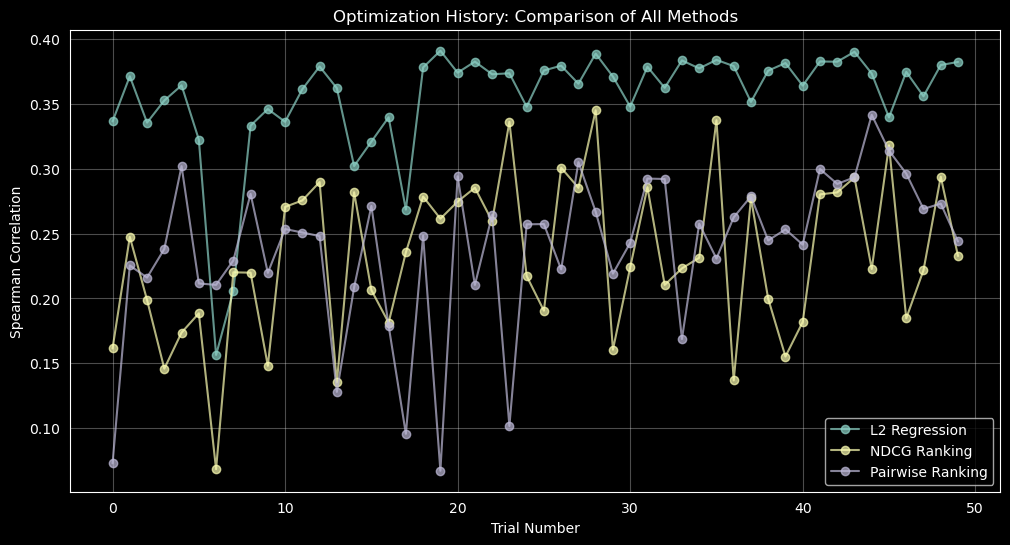


--- Evaluating L2 Model on Unseen Cell Lines (Test Set) ---


/home/michael/anaconda3/envs/tauso/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [16:57:56] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1770963487554/work/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mean Spearman Correlation (L2 Model): 0.3496

--- Evaluating NDCG Model on Unseen Cell Lines (Test Set) ---


/home/michael/anaconda3/envs/tauso/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [16:57:59] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1770963487554/work/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mean Spearman Correlation (NDCG Model): 0.3531

--- Evaluating Pairwise Model on Unseen Cell Lines (Test Set) ---


/home/michael/anaconda3/envs/tauso/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [16:58:02] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1770963487554/work/src/learner.cc:782: 
Parameters: { "num_boost_round" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mean Spearman Correlation (Pairwise Model): 0.3585


In [12]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 5. Combined Plotting Function
# ---------------------------------------------------------
def plot_combined_history(df_dict):
    plt.figure(figsize=(12, 6))

    # Loop through the dictionary and plot each method's trial values
    for name, df in df_dict.items():
        # Using marker='o' and linestyle='-' to show the path of the trials
        plt.plot(df['number'], df['value'], marker='o', linestyle='-', alpha=0.7, label=name)

    plt.title("Optimization History: Comparison of All Methods")
    plt.xlabel("Trial Number")
    plt.ylabel("Spearman Correlation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Pass all results into the new combined plotting function
plot_combined_history({
    "L2 Regression": df_results_l2,
    "NDCG Ranking": df_results_ndcg,
    "Pairwise Ranking": df_results_pairwise
})

# ---------------------------------------------------------
# 6. Evaluate Utility on Final Test Set
# ---------------------------------------------------------
def evaluate_final_utility(study, objective, name):
    print(f"\n--- Evaluating {name} on Unseen Cell Lines (Test Set) ---")
    best_params = study.best_params
    best_params['tree_method'] = 'hist'
    best_params['device'] = 'cuda'
    best_params['objective'] = objective

    # FIXED: Ensure linear gain is applied for final evaluation on BOTH rankers
    if 'rank' in objective:
        best_params['ndcg_exp_gain'] = False

    if "reg" in objective:
        model = xgb.XGBRegressor(**best_params, random_state=42)
        model.fit(X_train, y_train)
    else:
        model = xgb.XGBRanker(**best_params, random_state=42)
        model.fit(X_train, y_train, qid=qid_train)

    preds = model.predict(X_test)
    final_spearman = calculate_fast_spearman(preds, test_eval_groups)

    print(f"Mean Spearman Correlation ({name}): {final_spearman:.4f}")
    return final_spearman

spearman_l2 = evaluate_final_utility(study_l2, 'reg:squarederror', "L2 Model")
spearman_ndcg = evaluate_final_utility(study_ndcg, 'rank:ndcg', "NDCG Model")
spearman_pairwise = evaluate_final_utility(study_pairwise, 'rank:pairwise', "Pairwise Model")

In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb
from scipy.stats import spearmanr
from tqdm.auto import tqdm

# --- SELECTION THRESHOLDS ---
PARSIMONY_TOLERANCE = 0.015 # Accept a model if it is within 0.015 of the absolute maximum Spearman
EARLY_STOP_DROP = 0.05      # Stop the loop if performance drops 0.05 below the best seen so far
# ----------------------------

# 1. Fast Tracking Functions & Setup
X_train_np, y_train_np = train_df[features].values, train_df[INHIBITION].values
X_val_np, y_val_np = val_df[features].values, val_df[INHIBITION].values
X_test_np, y_test_np = test_df[features].values, test_df[INHIBITION].values

feat_to_idx = {feat: i for i, feat in enumerate(features)}

def get_large_cohort_indices(df):
    return [group.index.values for _, group in df.groupby('cohort_id') if len(group) >= 50]

train_eval_idx = get_large_cohort_indices(train_df)
val_eval_idx = get_large_cohort_indices(val_df)
test_eval_idx = get_large_cohort_indices(test_df)

def calculate_metrics(preds, y_true, eval_groups):
    spearmans, top_1_means, top_5_means = [], [], []
    for idxs in eval_groups:
        t_vals = y_true[idxs]
        p_vals = preds[idxs]

        corr, _ = spearmanr(t_vals, p_vals)
        if not np.isnan(corr):
            spearmans.append(corr)

        n = len(t_vals)
        k1, k5 = max(1, int(n * 0.01)), max(1, int(n * 0.05))
        sorted_indices = np.argsort(p_vals)[::-1]

        top_1_means.append(np.mean(t_vals[sorted_indices[:k1]]))
        top_5_means.append(np.mean(t_vals[sorted_indices[:k5]]))

    return {
        'spearman': np.nanmean(spearmans) if spearmans else 0.0,
        'top1_inhibition': np.nanmean(top_1_means) if top_1_means else 0.0,
        'top5_inhibition': np.nanmean(top_5_means) if top_5_means else 0.0
    }

# 2. Extract Best Optuna Parameters
best_l2_params = study_l2.best_params.copy()
best_l2_params.update({'tree_method': 'hist', 'device': 'cuda', 'objective': 'reg:squarederror'})
num_rounds = best_l2_params.pop('num_boost_round', best_l2_params.pop('n_estimators', 1000))

# 3. Execution Loop
current_features = list(features)
selection_history = []
max_spearman_seen = -1.0

total_iters = ((len(current_features) - 100) // 5) + 100 if len(current_features) > 100 else len(current_features)
pbar = tqdm(total=total_iters, desc="Dropping Features")

while len(current_features) > 0:
    curr_idxs = [feat_to_idx[f] for f in current_features]

    dtrain = xgb.DMatrix(X_train_np[:, curr_idxs], label=y_train_np, feature_names=current_features)
    dval = xgb.DMatrix(X_val_np[:, curr_idxs], label=y_val_np, feature_names=current_features)
    dtest = xgb.DMatrix(X_test_np[:, curr_idxs], label=y_test_np, feature_names=current_features)

    bst = xgb.train(
        best_l2_params, dtrain, num_boost_round=num_rounds,
        evals=[(dval, 'val')], early_stopping_rounds=50, verbose_eval=False
    )

    metrics_train = calculate_metrics(bst.predict(dtrain), y_train_np, train_eval_idx)
    metrics_val = calculate_metrics(bst.predict(dval), y_val_np, val_eval_idx)
    metrics_test = calculate_metrics(bst.predict(dtest), y_test_np, test_eval_idx)

    val_spear = metrics_val['spearman']
    if val_spear > max_spearman_seen:
        max_spearman_seen = val_spear

    step_data = {
        'num_features': len(current_features),
        'features_list': list(current_features),
        'train_spearman': metrics_train['spearman'],
        'train_top1': metrics_train['top1_inhibition'],
        'train_top5': metrics_train['top5_inhibition'],
        'val_spearman': val_spear,
        'val_top1': metrics_val['top1_inhibition'],
        'val_top5': metrics_val['top5_inhibition'],
        'test_spearman': metrics_test['spearman'],
        'test_top1': metrics_test['top1_inhibition'],
        'test_top5': metrics_test['top5_inhibition'],
    }

    # EARLY STOPPING CHECK
    if val_spear < (max_spearman_seen - EARLY_STOP_DROP):
        print(f"\n[Early Stop] Val Spearman dropped to {val_spear:.4f} (Peak was {max_spearman_seen:.4f}). Halting to save time.")
        step_data['dropped_features'] = []
        selection_history.append(step_data)
        break

    if len(current_features) == 1:
        step_data['dropped_features'] = current_features
        selection_history.append(step_data)
        pbar.update(1)
        break

    imp_dict = bst.get_score(importance_type='gain')
    feat_importances = {f: imp_dict.get(f, 0.0) for f in current_features}
    sorted_feats = sorted(feat_importances.items(), key=lambda x: x[1])

    drop_n = 5 if len(current_features) > 100 else 1
    drop_n = min(drop_n, len(current_features) - 1)
    feats_to_drop = [x[0] for x in sorted_feats[:drop_n]]

    step_data['dropped_features'] = feats_to_drop
    selection_history.append(step_data)

    print(f"\n[Features: {len(current_features)} -> {len(current_features) - drop_n}]")
    print(f"  Train -> Spear: {metrics_train['spearman']:.4f} | Top 1%: {metrics_train['top1_inhibition']:.2f} | Top 5%: {metrics_train['top5_inhibition']:.2f}")
    print(f"  Val   -> Spear: {val_spear:.4f} | Top 1%: {metrics_val['top1_inhibition']:.2f} | Top 5%: {metrics_val['top5_inhibition']:.2f}")
    print(f"  Test  -> Spear: {metrics_test['spearman']:.4f} | Top 1%: {metrics_test['top1_inhibition']:.2f} | Top 5%: {metrics_test['top5_inhibition']:.2f}")

    current_features = [f for f in current_features if f not in feats_to_drop]
    pbar.update(1)

pbar.close()

# 4. PARSIMONIOUS SELECTION
df_backward_selection = pd.DataFrame(selection_history)

absolute_peak = df_backward_selection['val_spearman'].max()
threshold = absolute_peak - PARSIMONY_TOLERANCE

# Keep only iterations that are within the tolerance of the absolute peak
candidates = df_backward_selection[df_backward_selection['val_spearman'] >= threshold]

# Out of those highly-performing subsets, pick the one with the MINIMUM number of features
best_row = candidates.loc[candidates['num_features'].idxmin()]
abs_peak_row = df_backward_selection.loc[df_backward_selection['val_spearman'].idxmax()]

print("\n" + "="*50)
print(f"🏆 OPTIMAL PARSIMONIOUS MODEL FOUND")
print("="*50)
print(f"Absolute Peak Spearman : {absolute_peak:.4f} (at {abs_peak_row['num_features']} features)")
print(f"Parsimonious Selection : {best_row['val_spearman']:.4f} (at {best_row['num_features']} features)")
print(f"Unseen Test Spearman   : {best_row['test_spearman']:.4f}")
print(f"Test Top 1% True Inhib : {best_row['test_top1']:.2f}")

Dropping Features:   0%|          | 0/204 [00:00<?, ?it/s]


[Features: 623 -> 618]
  Train -> Spear: 0.9317 | Top 1%: 88.35 | Top 5%: 83.83
  Val   -> Spear: 0.3911 | Top 1%: 62.43 | Top 5%: 60.91
  Test  -> Spear: 0.3989 | Top 1%: 70.03 | Top 5%: 64.68

[Features: 618 -> 613]
  Train -> Spear: 0.9360 | Top 1%: 88.38 | Top 5%: 84.17
  Val   -> Spear: 0.3838 | Top 1%: 61.63 | Top 5%: 59.76
  Test  -> Spear: 0.3936 | Top 1%: 67.30 | Top 5%: 63.72

[Features: 613 -> 608]
  Train -> Spear: 0.9285 | Top 1%: 88.37 | Top 5%: 83.86
  Val   -> Spear: 0.3867 | Top 1%: 66.97 | Top 5%: 66.22
  Test  -> Spear: 0.3935 | Top 1%: 68.12 | Top 5%: 63.93

[Features: 608 -> 603]
  Train -> Spear: 0.8924 | Top 1%: 87.59 | Top 5%: 82.73
  Val   -> Spear: 0.3906 | Top 1%: 65.05 | Top 5%: 62.70
  Test  -> Spear: 0.3905 | Top 1%: 69.61 | Top 5%: 63.11

[Features: 603 -> 598]
  Train -> Spear: 0.9345 | Top 1%: 88.81 | Top 5%: 83.94
  Val   -> Spear: 0.3917 | Top 1%: 63.27 | Top 5%: 63.15
  Test  -> Spear: 0.3905 | Top 1%: 69.21 | Top 5%: 63.01

[Features: 598 -> 593]
 

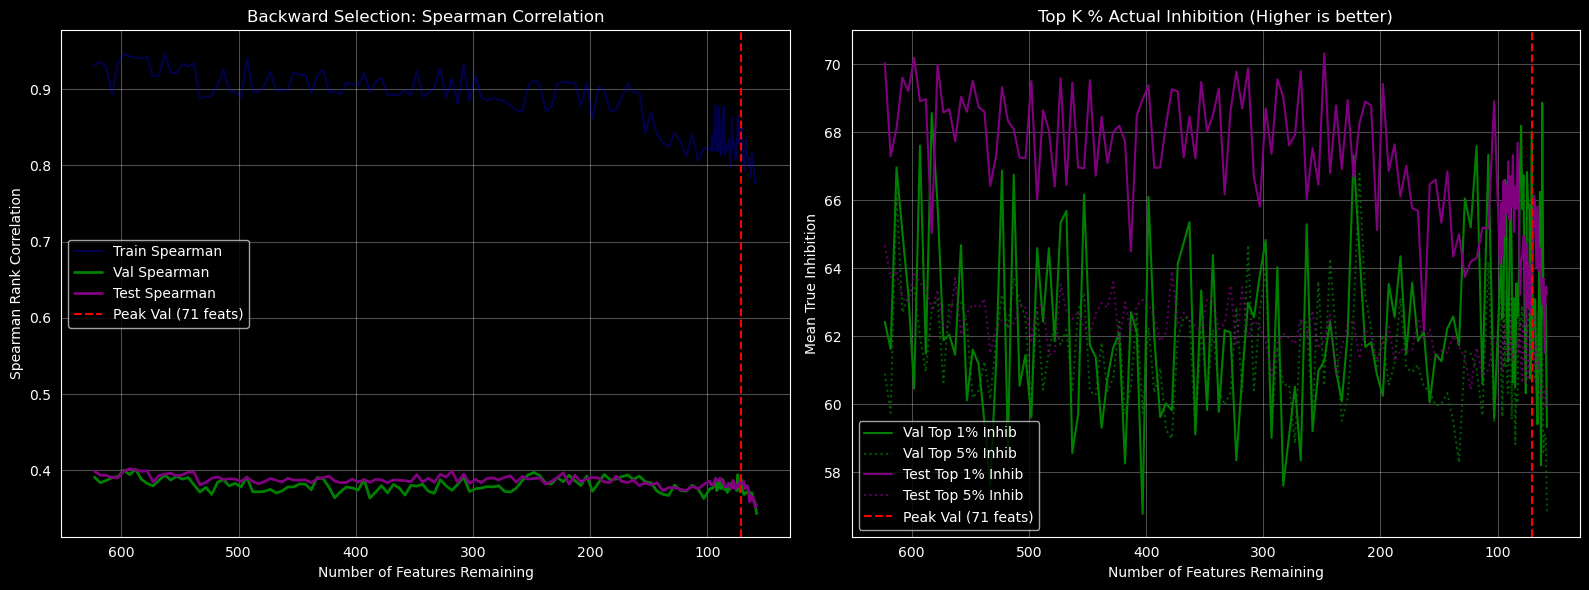

In [17]:
import matplotlib.pyplot as plt

# Retrieve optimal feature count for the marker line
opt_feat_count = best_row['num_features']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Spearman Correlation ---
axes[0].plot(df_backward_selection['num_features'], df_backward_selection['train_spearman'], label='Train Spearman', color='blue', alpha=0.3)
axes[0].plot(df_backward_selection['num_features'], df_backward_selection['val_spearman'], label='Val Spearman', color='green', linewidth=2)
axes[0].plot(df_backward_selection['num_features'], df_backward_selection['test_spearman'], label='Test Spearman', color='purple', linewidth=2)
axes[0].axvline(x=opt_feat_count, color='red', linestyle='--', label=f'Peak Val ({opt_feat_count} feats)')

axes[0].invert_xaxis()
axes[0].set_title("Backward Selection: Spearman Correlation")
axes[0].set_xlabel("Number of Features Remaining")
axes[0].set_ylabel("Spearman Rank Correlation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Top K Performance ---
# Showing Validation & Test Top 1% and 5% Mean Inhibitions
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['val_top1'], label='Val Top 1% Inhib', color='green', linestyle='-')
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['val_top5'], label='Val Top 5% Inhib', color='green', linestyle=':', alpha=0.7)
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['test_top1'], label='Test Top 1% Inhib', color='purple', linestyle='-')
axes[1].plot(df_backward_selection['num_features'], df_backward_selection['test_top5'], label='Test Top 5% Inhib', color='purple', linestyle=':', alpha=0.7)
axes[1].axvline(x=opt_feat_count, color='red', linestyle='--', label=f'Peak Val ({opt_feat_count} feats)')

axes[1].invert_xaxis()
axes[1].set_title("Top K % Actual Inhibition (Higher is better)")
axes[1].set_xlabel("Number of Features Remaining")
axes[1].set_ylabel("Mean True Inhibition")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
from tqdm.auto import tqdm

# Ensure optimal_features is defined from the backward selection step
optimal_features = best_row['features_list']

print(f"Training final GlobalModel with {len(optimal_features)} optimal features...")

# 1. Build Native DMatrices
opt_idxs = [feat_to_idx[f] for f in optimal_features]
dtrain_global = xgb.DMatrix(X_train_np[:, opt_idxs], label=y_train_np, feature_names=optimal_features)
dval_global = xgb.DMatrix(X_val_np[:, opt_idxs], label=y_val_np, feature_names=optimal_features)

# 2. Train Global Model
GlobalModel = xgb.train(
    best_l2_params,
    dtrain_global,
    num_boost_round=num_rounds,
    evals=[(dval_global, 'val')],
    early_stopping_rounds=50,
    verbose_eval=False
)

# 3. Save to Disk
GlobalModel.save_model("GlobalModel.json")
print("✅ Model saved successfully as 'GlobalModel.json'")

# 4. Extract Native XGBoost Gain
imp_gain = GlobalModel.get_score(importance_type='gain')
df_gain = pd.DataFrame(list(imp_gain.items()), columns=['Feature', 'Gain'])
df_gain = df_gain.sort_values(by='Gain', ascending=False).reset_index(drop=True)

# ---------------------------------------------------------
# Group-Aware Permutation Importance
# ---------------------------------------------------------
print("\nCalculating Group-Aware Permutation Importance on Validation Set...")

baseline_preds = GlobalModel.predict(dval_global)
baseline_spearman = calculate_metrics(baseline_preds, y_val_np, val_eval_idx)['spearman']

df_eval = val_df[['cohort_id'] + optimal_features].copy()
perm_results = []

for feature in tqdm(optimal_features, desc="Permuting Features"):
    X_shuffled_np = X_val_np[:, opt_idxs].copy()
    feat_idx_in_shuffled = optimal_features.index(feature)

    # Check if the feature is perfectly constant within every single cohort_id
    is_constant = df_eval.groupby('cohort_id')[feature].nunique().max() == 1

    if is_constant:
        # --- COHORT-LEVEL SWAP ---
        cohort_mapping = df_eval[['cohort_id', feature]].drop_duplicates().reset_index(drop=True)
        cohort_mapping['shuffled_val'] = np.random.permutation(cohort_mapping[feature].values)
        shuffled_col = df_eval['cohort_id'].map(cohort_mapping.set_index('cohort_id')['shuffled_val'])

        X_shuffled_np[:, feat_idx_in_shuffled] = shuffled_col.values
        perm_type = "Cohort-Level"
    else:
        # --- ROW-LEVEL SWAP ---
        X_shuffled_np[:, feat_idx_in_shuffled] = np.random.permutation(X_shuffled_np[:, feat_idx_in_shuffled])
        perm_type = "Row-Level"

    dtemp = xgb.DMatrix(X_shuffled_np, feature_names=optimal_features)
    shuffled_preds = GlobalModel.predict(dtemp)
    shuffled_spearman = calculate_metrics(shuffled_preds, y_val_np, val_eval_idx)['spearman']

    perm_results.append({
        'Feature': feature,
        'Importance_Drop': baseline_spearman - shuffled_spearman,
        'Permutation_Type': perm_type
    })

df_perm = pd.DataFrame(perm_results)

# Split into the two distinct tracking DataFrames
df_perm_cohort = df_perm[df_perm['Permutation_Type'] == 'Cohort-Level'].sort_values(by='Importance_Drop', ascending=False).reset_index(drop=True)
df_perm_row = df_perm[df_perm['Permutation_Type'] == 'Row-Level'].sort_values(by='Importance_Drop', ascending=False).reset_index(drop=True)

Training final GlobalModel with 71 optimal features...
✅ Model saved successfully as 'GlobalModel.json'

Calculating Group-Aware Permutation Importance on Validation Set...


Permuting Features:   0%|          | 0/71 [00:00<?, ?it/s]

/tmp/ipykernel_24325/1248799855.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gain', y='Feature', data=df_gain.head(TOP_N), ax=axes[0], palette='viridis')
/tmp/ipykernel_24325/1248799855.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_cohort.head(TOP_N), ax=axes[1], palette='flare')
/tmp/ipykernel_24325/1248799855.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_row.head(TOP_N), ax=axes[2], palette='crest')


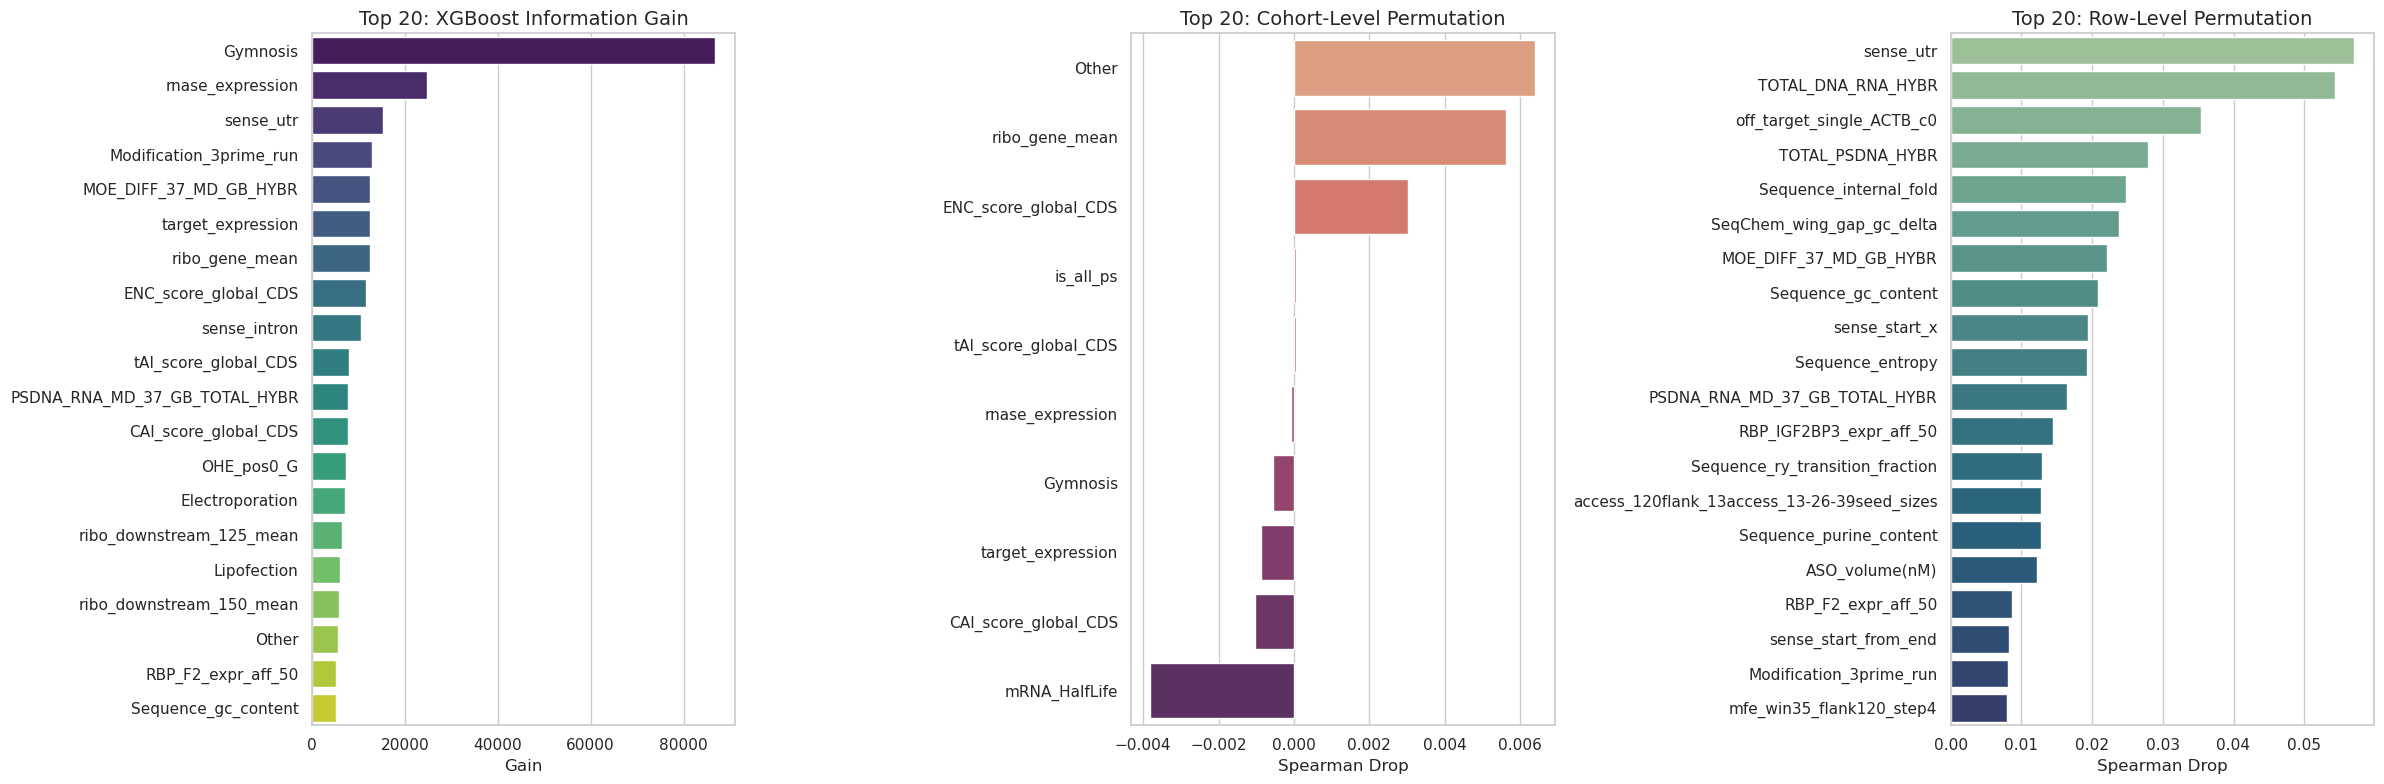


ALL FEATURES: NATIVE XGBOOST GAIN
                                    Feature         Gain
                                   Gymnosis 86774.546875
                           rnase_expression 24807.373047
                                  sense_utr 15243.091797
                    Modification_3prime_run 12864.752930
                     MOE_DIFF_37_MD_GB_HYBR 12542.732422
                          target_expression 12448.127930
                             ribo_gene_mean 12422.927734
                       ENC_score_global_CDS 11660.583008
                               sense_intron 10688.175781
                       tAI_score_global_CDS  7988.175781
              PSDNA_RNA_MD_37_GB_TOTAL_HYBR  7763.794434
                       CAI_score_global_CDS  7756.896973
                                 OHE_pos0_G  7356.378906
                            Electroporation  7034.887207
                   ribo_downstream_125_mean  6504.529297
                                Lipofection  5979.438

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
TOP_N = 20

# --- Plot 1: XGBoost Gain ---
sns.barplot(x='Gain', y='Feature', data=df_gain.head(TOP_N), ax=axes[0], palette='viridis')
axes[0].set_title(f"Top {TOP_N}: XGBoost Information Gain", fontsize=14)
axes[0].set_xlabel("Gain")
axes[0].set_ylabel("")

# --- Plot 2: Cohort-Level Permutation ---
sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_cohort.head(TOP_N), ax=axes[1], palette='flare')
axes[1].set_title(f"Top {TOP_N}: Cohort-Level Permutation", fontsize=14)
axes[1].set_xlabel("Spearman Drop")
axes[1].set_ylabel("")

# --- Plot 3: Row-Level Permutation ---
sns.barplot(x='Importance_Drop', y='Feature', data=df_perm_row.head(TOP_N), ax=axes[2], palette='crest')
axes[2].set_title(f"Top {TOP_N}: Row-Level Permutation", fontsize=14)
axes[2].set_xlabel("Spearman Drop")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print Exhaustive Descending Lists
# ---------------------------------------------------------
print("\n" + "="*60)
print("ALL FEATURES: NATIVE XGBOOST GAIN")
print("="*60)
print(df_gain.to_string(index=False))

print("\n" + "="*60)
print("ALL FEATURES: COHORT-LEVEL PERMUTATION IMPORTANCE")
print("(Features constant across a cohort)")
print("="*60)
print(df_perm_cohort[['Feature', 'Importance_Drop']].to_string(index=False))

print("\n" + "="*60)
print("ALL FEATURES: ROW-LEVEL PERMUTATION IMPORTANCE")
print("(Features that vary within a cohort)")
print("="*60)
print(df_perm_row[['Feature', 'Importance_Drop']].to_string(index=False))

/tmp/ipykernel_24325/2280142165.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


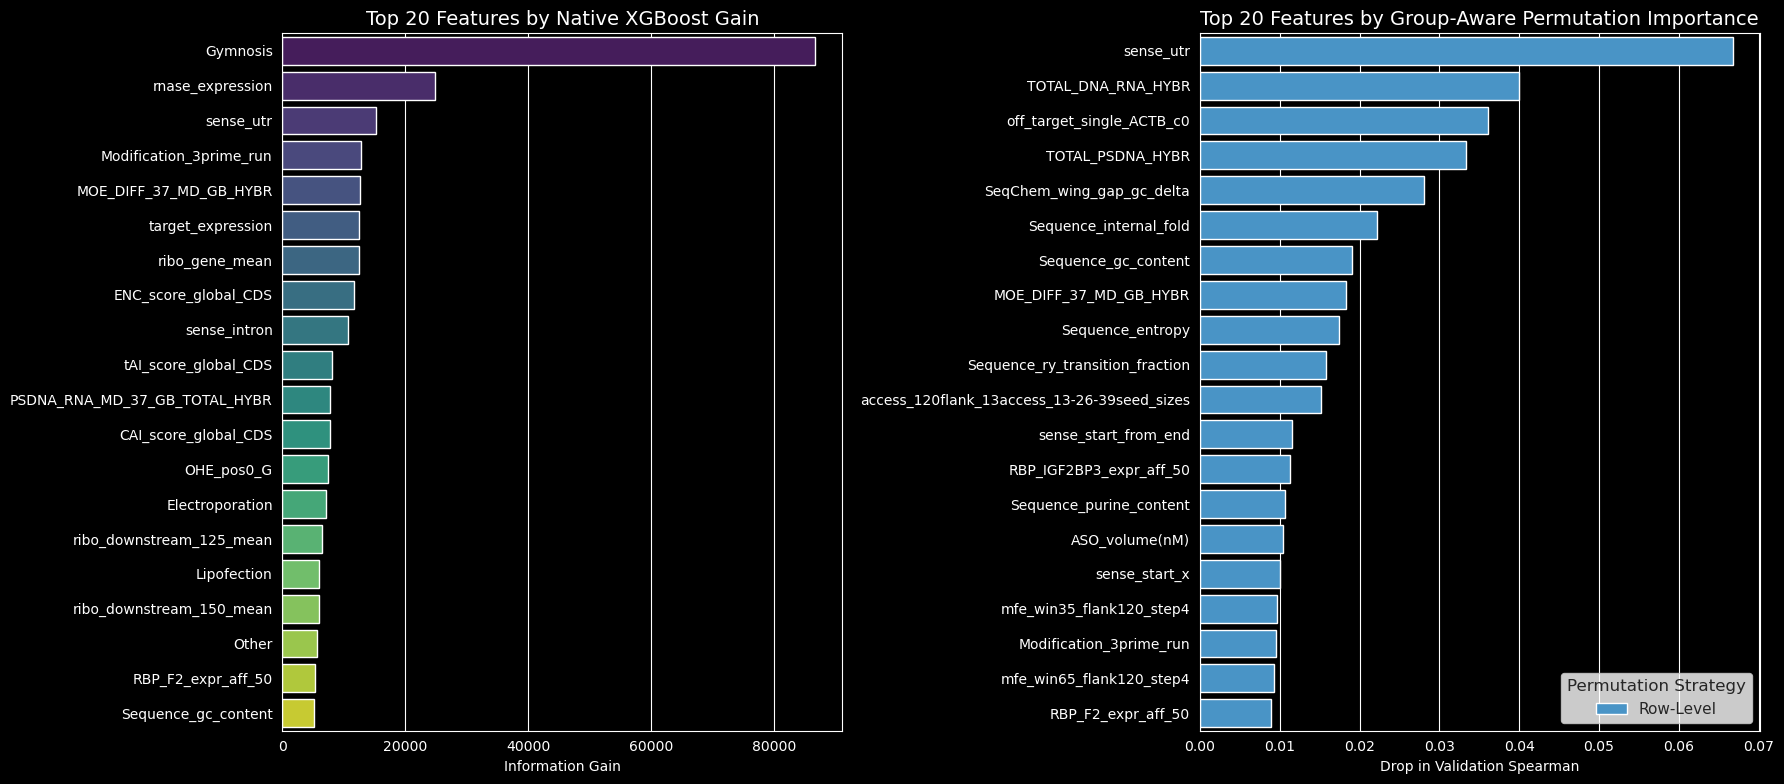


--- Top 10 Most Critical Features (Permutation) ---
                        Feature  Importance_Drop Permutation_Type
                      sense_utr         0.066777        Row-Level
             TOTAL_DNA_RNA_HYBR         0.039958        Row-Level
      off_target_single_ACTB_c0         0.036052        Row-Level
               TOTAL_PSDNA_HYBR         0.033285        Row-Level
      SeqChem_wing_gap_gc_delta         0.028068        Row-Level
         Sequence_internal_fold         0.022149        Row-Level
            Sequence_gc_content         0.019031        Row-Level
         MOE_DIFF_37_MD_GB_HYBR         0.018298        Row-Level
               Sequence_entropy         0.017373        Row-Level
Sequence_ry_transition_fraction         0.015832        Row-Level


In [21]:
# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="whitegrid")

# Top 20 Features to plot
TOP_N = 20

# --- Plot 1: Native XGBoost Gain ---
sns.barplot(
    x='Gain', y='Feature',
    data=df_gain.head(TOP_N),
    ax=axes[0], palette='viridis'
)
axes[0].set_title(f"Top {TOP_N} Features by Native XGBoost Gain", fontsize=14)
axes[0].set_xlabel("Information Gain")
axes[0].set_ylabel("")

# --- Plot 2: Permutation Importance ---
# We use 'hue' to color-code whether the feature was swapped by Cohort or Row
sns.barplot(
    x='Importance_Drop', y='Feature',
    hue='Permutation_Type', dodge=False,
    data=df_perm.head(TOP_N),
    ax=axes[1], palette={'Cohort-Level': '#e74c3c', 'Row-Level': '#3498db'}
)
axes[1].set_title(f"Top {TOP_N} Features by Group-Aware Permutation Importance", fontsize=14)
axes[1].set_xlabel("Drop in Validation Spearman")
axes[1].set_ylabel("")
axes[1].legend(title="Permutation Strategy", loc="lower right")

plt.tight_layout()
plt.show()

# Print summary of the top features
print("\n--- Top 10 Most Critical Features (Permutation) ---")
print(df_perm.head(10).to_string(index=False))